In [20]:
1+1

2

In [21]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.presets import get_list_of_presets
from src.tools.read.rerank.load_rerank_raw import load_retrieval_dataframes
from src.tools.read.datasets.load_tasks import load_tasks_dataframes
from src.tools.read.chunks.load_chunks import load_chunks_dataframes


load_dotenv()

RERANK_DIR = Path(os.getenv("RERANK_DIR"))
DATASETS_DIR = Path(os.getenv("DATASETS_DIR"))
CHUNKS_DIR = Path(os.getenv("CHUNKS_DIR"))


with open("params.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

with open("params_lit.yaml", "r", encoding="utf-8") as f:
    params_lit = yaml.safe_load(f)

In [22]:
def create_configs(params):
    
    datasets_cfg = params.get("preprocess_datasets").get("datasets")
    if not datasets_cfg:
        raise ValueError("Nie znaleziono datasets_download w params.yaml")

    chunking_cfg = params.get("chunking").get("methods")
    if not chunking_cfg:
        raise ValueError("Nie znaleziono chunking_methods w params.yaml")

    embed_cfg = params.get("vector_embed").get("methods")
    if not embed_cfg:
        raise ValueError("Nie znaleziono vector_embed_methods w params.yaml")

    search_cfg = params.get("search").get("methods")
    if not embed_cfg:
        raise ValueError("Nie znaleziono search methods w params.yaml")

    rerank_cfg = params.get("rerank").get("methods")
    if not embed_cfg:
        raise ValueError("Nie znaleziono rerank methods w params.yaml")

    analyze_cfg = params.get("analyze_retrieval").get("methods")
    if not analyze_cfg:
        raise ValueError("Nie znaleziono analyze_retrieval_methods w params.yaml")

    splits = params.get("chunking").get("splits")
    if not splits:
        raise ValueError("Nie znaleziono splits w params.yaml")

    dataset_names, dataset_params_names = get_list_of_presets(datasets_cfg)
    chunking_names, chunking_params_names = get_list_of_presets(chunking_cfg)
    embed_names, embed_params_names = get_list_of_presets(embed_cfg)
    search_names, search_params_names = get_list_of_presets(search_cfg)
    rerank_names, rerank_params_names = get_list_of_presets(rerank_cfg)

    chunks_configs = []
    retrieval_configs = []
    tasks_configs = []
    for split in splits:
        for dataset, dataset_params in zip(dataset_names, dataset_params_names):
            tasks_configs.append({
                "dataset_name": dataset,
                "dataset_params_name": dataset_params,
                "split_name": split
            })
            for chunking, chunking_params in zip(chunking_names, chunking_params_names):
                chunks_configs.append({
                    "dataset_name": dataset,
                    "dataset_params_name": dataset_params,
                    "chunking_name": chunking,
                    "chunking_params_name": chunking_params,
                    "split_name": split
                })
                for embed, embed_params in zip(embed_names, embed_params_names):
                    if 'local' in embed_params:
                        continue
                    for search, search_params in zip(search_names, search_params_names):
                        for rerank, rerank_params in zip(rerank_names, rerank_params_names):

                            retrieval_configs.append({
                                "dataset_name": dataset,
                                "dataset_params_name": dataset_params,
                                "chunking_name": chunking,
                                "chunking_params_name": chunking_params,
                                "embed_name": embed,
                                "embed_params_name": embed_params,
                                "search_name": search,
                                "search_params_name": search_params,
                                "rerank_name": rerank,
                                "rerank_params_name": rerank_params,
                                "split_name": split
                            })
    return retrieval_configs, tasks_configs, chunks_configs

In [23]:
retrieval_configs, tasks_configs, chunks_configs = create_configs(params_lit)
lit_retrieval_df = load_retrieval_dataframes(RERANK_DIR, retrieval_configs)
lit_tasks_df = load_tasks_dataframes(data_dir=DATASETS_DIR, tasks_configs=tasks_configs)
lit_chunks_df = load_chunks_dataframes(CHUNKS_DIR, chunks_configs)

In [24]:
retrieval_configs, tasks_configs, chunks_configs = create_configs(params)
retrieval_df = load_retrieval_dataframes(RERANK_DIR, retrieval_configs)
tasks_df = load_tasks_dataframes(data_dir=DATASETS_DIR, tasks_configs=tasks_configs)
chunks_df = load_chunks_dataframes(CHUNKS_DIR, chunks_configs)
retrieval_df_old = retrieval_df.copy()

In [25]:
retrieval_df = pd.concat([retrieval_df, lit_retrieval_df])
tasks_df     = pd.concat([tasks_df, lit_tasks_df])
chunks_df    = pd.concat([chunks_df, lit_chunks_df])


In [26]:
retrieval_df

question_id  \
dataset_name        dataset_params_name chunking_name    chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name split_name               
infiniteBenchChoice default             chonkie_semantic norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      all                 Q0   
                                                                                                                                                                         all                 Q1   
                                                                                                                                                                         all                 Q2   
                                                                                                                                                                         all                 Q3   
                                                                                                                                                                         all                 Q4   
...                                                                                                                                                                                         ...   
literaryQA          default             sequential_hac   norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20_op   test             Q3781   
                                                                                                                                                                         test             Q3782   
                                                                                                                                                                         test             Q3783   
                                                                                                                                                                         test             Q3784   
                                                                                                                                                                         test             Q3785   

                                                                                                                                                                                                                         chunks_chosen  
dataset_name        dataset_params_name chunking_name    chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name split_name                                                     
infiniteBenchChoice default             chonkie_semantic norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      all         [448, 544, 595, 235, 236, 441, 358, 320, 124, ...  
                                                                                                                                                                         all         [582, 160, 644, 44, 601, 603, 722, 661, 789, 7...  
                                                                                                                                                                         all         [583, 230, 228, 577, 145, 307, 196, 234, 372, ...  
                                                                                                                                                                         all         [722, 504, 160, 813, 289, 497, 739, 582, 661, ...  
                                                                                                                                                                         all         [1045, 1046, 876, 1091, 886, 955, 999, 1000, 9...  
...          

In [27]:
retrieval_df["chunks_chosen"] = retrieval_df["chunks_chosen"].apply(lambda x: x[:10] if isinstance(x, list) else x)

In [28]:
print(retrieval_df.index.names)
print(retrieval_df.columns)

print(tasks_df.index.names)
print(tasks_df.columns)

print(chunks_df.index.names)
print(chunks_df.columns)

['dataset_name', 'dataset_params_name', 'chunking_name', 'chunking_params_name', 'embed_name', 'embed_params_name', 'search_name', 'search_params_name', 'rerank_name', 'rerank_params_name', 'split_name']
Index(['question_id', 'chunks_chosen'], dtype='object')
['dataset_name', 'dataset_params_name']
Index(['source_file', 'question_id', 'split_name', 'Aspect', 'Complexity',
       'Question', 'Options', 'Answers'],
      dtype='object')
['dataset_name', 'dataset_params_name', 'chunking_name', 'chunking_params_name', 'split_name']
Index(['source_file', 'chunk_id', 'start_index', 'end_index', 'tokens_len',
       'text', 'split', 'chunking_method', 'chunking_params', 'chunking_time'],
      dtype='object')


In [33]:
import numpy as np
import pandas as pd

# -----------------------------
# 1. Przygotowanie tabel
# -----------------------------

questions = tasks_df.reset_index()

chunks = chunks_df.reset_index()[
    [
        "dataset_name",
        "dataset_params_name",
        "chunking_name",
        "chunking_params_name",
        "split_name",
        "chunk_id",
        "source_file",
    ]
]

retrieval = retrieval_df.reset_index()

# -----------------------------
# 2. Rozwinięcie listy chunks_chosen z zachowaniem rankingu
# -----------------------------
# Zakładamy, że kolejność w chunks_chosen odpowiada kolejności
# zwróconej przez retriever (1 = najlepszy wynik).

def _make_ranks(lst):
    if isinstance(lst, (list, tuple)):
        return list(range(1, len(lst) + 1))
    return lst  # np.nan zostaje np.nan (explode zachowa wiersz)

retrieval["rank"] = retrieval["chunks_chosen"].apply(_make_ranks)

retrieval = retrieval.explode(["chunks_chosen", "rank"])
retrieval = retrieval.rename(columns={"chunks_chosen": "chunk_id"})
retrieval["rank"] = retrieval["rank"].astype("Int64")

# -----------------------------
# 3. Dołączenie source_file chunka
# -----------------------------

retrieval = retrieval.merge(
    chunks,
    on=[
        "dataset_name",
        "dataset_params_name",
        "chunking_name",
        "chunking_params_name",
        "split_name",
        "chunk_id",
    ],
    how="left",
)

# -----------------------------
# 4. Dołączenie source_file pytania
# -----------------------------

retrieval = retrieval.merge(
    questions[
        [
            "dataset_name",
            "dataset_params_name",
            "question_id",
            "split_name",
            "source_file",
        ]
    ].rename(columns={"source_file": "question_source_file"}),
    on=[
        "dataset_name",
        "dataset_params_name",
        "question_id",
        "split_name",
    ],
    how="left",
)

# -----------------------------
# 5. Good / Bad
# -----------------------------

retrieval["is_good"] = (
    retrieval["source_file"] == retrieval["question_source_file"]
).fillna(False)

GROUP_COLS = [
    "dataset_name",
    "dataset_params_name",
    "chunking_name",
    "chunking_params_name",
    "question_id",
    "split_name",
]

# -----------------------------
# 6. Statystyki pytanie × chunker
# -----------------------------

question_chunk_stats = (
    retrieval
    .groupby(GROUP_COLS, as_index=False)
    .agg(
        chosen_good_num=("is_good", "sum"),
        chosen_bad_num=("is_good", lambda x: (~x).sum()),
    )
)

question_chunk_stats["chosen_good"] = question_chunk_stats["chosen_good_num"] > 0
question_chunk_stats["chosen_bad"] = question_chunk_stats["chosen_bad_num"] > 0

# -----------------------------
# 6a. Accuracy@5 (hit w top-5 rankingu)
# -----------------------------

hit_at_5 = (
    retrieval[retrieval["rank"] <= 5]
    .groupby(GROUP_COLS)["is_good"]
    .any()
    .rename("accuracy_at_5")
    .reset_index()
)

question_chunk_stats = question_chunk_stats.merge(
    hit_at_5, on=GROUP_COLS, how="left"
)
question_chunk_stats["accuracy_at_5"] = (
    question_chunk_stats["accuracy_at_5"].fillna(False)
)

# -----------------------------
# 6b. NDCG@10
# -----------------------------

def dcg_at_k(rels_in_rank_order, k=10):
    rels_in_rank_order = rels_in_rank_order[:k]
    return sum(
        rel / np.log2(pos + 2)  # pos=0 -> ranga 1 -> log2(2)
        for pos, rel in enumerate(rels_in_rank_order)
    )

def idcg_at_k(num_relevant, k=10):
    n = min(num_relevant, k)
    return sum(1 / np.log2(pos + 2) for pos in range(n))

# ile chunków danego source_file istnieje w ogóle (dla danej konfiguracji
# chunkowania) - potrzebne jako "idealna" liczba trafień do IDCG
relevant_counts = (
    chunks
    .groupby(
        [
            "dataset_name",
            "dataset_params_name",
            "chunking_name",
            "chunking_params_name",
            "split_name",
            "source_file",
        ]
    )
    .size()
    .rename("num_relevant_chunks")
    .reset_index()
)

question_source = (
    retrieval[GROUP_COLS + ["question_source_file"]]
    .drop_duplicates()
)

question_relevant_counts = question_source.merge(
    relevant_counts.rename(columns={"source_file": "question_source_file"}),
    on=[
        "dataset_name",
        "dataset_params_name",
        "chunking_name",
        "chunking_params_name",
        "split_name",
        "question_source_file",
    ],
    how="left",
)
question_relevant_counts["num_relevant_chunks"] = (
    question_relevant_counts["num_relevant_chunks"].fillna(0).astype(int)
)

dcg = (
    retrieval
    .sort_values(GROUP_COLS + ["rank"])
    .groupby(GROUP_COLS)["is_good"]
    .apply(lambda s: dcg_at_k(s.astype(int).tolist(), k=10))
    .rename("dcg_at_10")
    .reset_index()
)

ndcg = dcg.merge(question_relevant_counts, on=GROUP_COLS, how="left")
ndcg["idcg_at_10"] = ndcg["num_relevant_chunks"].apply(lambda n: idcg_at_k(n, k=10))
ndcg["ndcg_at_10"] = np.where(
    ndcg["idcg_at_10"] > 0,
    ndcg["dcg_at_10"] / ndcg["idcg_at_10"],
    0.0,
)

question_chunk_stats = question_chunk_stats.merge(
    ndcg[GROUP_COLS + ["ndcg_at_10"]], on=GROUP_COLS, how="left"
)

# -----------------------------
# 7. Dołączenie metadanych pytania
# -----------------------------

question_chunk_stats = question_chunk_stats.merge(
    questions,
    on=[
        "dataset_name",
        "dataset_params_name",
        "question_id",
        "split_name",
    ],
    how="left",
)

# -----------------------------
# 8. Answerability dla datasetu
# -----------------------------

answerability = (
    question_chunk_stats
    .groupby(
        [
            "dataset_name",
            "dataset_params_name",
            "question_id",
            "split_name",
        ]
    )["chosen_good"]
    .agg(all_hit="all", any_hit="any")
    .reset_index()
)

answerability["answerable"] = "partial_hit"
answerability.loc[answerability["all_hit"], "answerable"] = "all_hit"
answerability.loc[~answerability["any_hit"], "answerable"] = "no_hit"

# -----------------------------
# 9. Finalna tabela do wykresów
# -----------------------------

question_answerability = questions.merge(
    answerability[
        [
            "dataset_name",
            "dataset_params_name",
            "question_id",
            "split_name",
            "answerable",
        ]
    ],
    on=[
        "dataset_name",
        "dataset_params_name",
        "question_id",
        "split_name",
    ],
    how="left",
)

# -----------------------------
# 10. Podsumowanie Accuracy@5 / NDCG@10 per konfiguracja chunkowania
# -----------------------------

metrics_summary = (
    question_chunk_stats
    .groupby(
        [
            "dataset_name",
            "dataset_params_name",
            "chunking_name",
            "chunking_params_name",
        ],
        as_index=False,
    )
    .agg(
        accuracy_at_5=("accuracy_at_5", "mean"),
        ndcg_at_10=("ndcg_at_10", "mean"),
    )
)

In [37]:
metrics_summary

,dataset_name,dataset_params_name,chunking_name,chunking_params_name,accuracy_at_5,ndcg_at_10
0,infiniteBenchChoice,default,chonkie_semantic,norm,0.908297,0.665003
1,infiniteBenchChoice,default,fixed_size,norm_token,0.921397,0.710585
2,infiniteBenchChoice,default,lumber,default_vllm,0.921397,0.715535
3,infiniteBenchChoice,default,max_min,norm,0.899563,0.671224
4,infiniteBenchChoice,default,neural,default,0.851528,0.571099
5,infiniteBenchChoice,default,recursive,norm,0.912664,0.708778
6,infiniteBenchChoice,default,recursive_semantic,norm,0.895197,0.709960
7,infiniteBenchChoice,default,sequential_hac,norm,0.864629,0.626513
8,infiniteBenchQA,default,chonkie_semantic,norm,0.891738,0.673967
9,infiniteBenchQA,default,fixed_size,norm_token,0.900285,0.714777


,dataset_name,dataset_params_name,source_file,question_id,split_name,Aspect,Complexity,Question,Options,Answers,answerable
653,novelQA,default,B13,Q0340,all,times,mh,"Has the object Sherry appeared? If so, how man...","[Yes, 2, No, never, Yes, 1, Yes, 3]",NaN,no_hit
667,novelQA,default,B13,Q0354,all,meaning,mh,"In the novel The Sun Also Rises, explain the m...",[It represents Jake's inability to control his...,NaN,no_hit
720,novelQA,default,B10,Q0394,all,character,dtl,In which chapter is Carpenter mentioned?,"[chapter three, chapter five, chapter eight, c...",NaN,no_hit
726,novelQA,default,B10,Q0400,all,character,dtl,In which chapter is James (not King James in t...,"[Chapter Three, Chapter Eight, Chapter One, Ch...",NaN,no_hit
742,novelQA,default,B72,Q2282,all,meaning,sh,Why did Futaki come to visit Schmidt secretly?,"[To discuss the harvest plans., To borrow some...",NaN,no_hit
...,...,...,...,...,...,...,...,...,...,...,...
2833,novelQA,default,B79,Q1123,all,plot,mh,Which part of Louis' body got hurt before Miri...,"[One of his eyes., His right arm., His left le...",NaN,no_hit
2834,novelQA,default,B79,Q1124,all,meaning,mh,Why did Miriam accept Paul's interview and tol...,[Because Paul had promised her a large sum of ...,NaN,no_hit
2835,novelQA,default,B79,Q1125,all,plot,sh,How did Harriet deal with the remain of her hu...,"[Buried him in the backyard., Left his body in...",NaN,no_hit
2836,novelQA,default,B79,Q1126,all,meaning,sh,Why did Miriam decide not to commit suicide?,[Because she realized she didn't want to leave...,NaN,no_hit


In [36]:
question_answerability.groupby(
    ["dataset_name", "answerable"]
).size()


dataset_name         answerable 
infiniteBenchChoice  all_hit         191
                     no_hit           10
                     partial_hit      28
infiniteBenchQA      all_hit         290
                     no_hit           15
                     partial_hit      46
literaryQA           all_hit        2951
                     no_hit          193
                     partial_hit     641
novelQA              all_hit        1180
                     no_hit          789
                     partial_hit     314
dtype: int64

In [ ]:
question_answerability.groupby(
    ["dataset_name", "answerable"]
).size()

question_answerability.groupby(
    ["dataset_name", "Aspect", "answerable"]
).size()

question_answerability.groupby(
    ["dataset_name", "Complexity", "answerable"]
).size()

dataset_name         answerable 
infiniteBenchChoice  all_hit         183
                     no_hit           10
                     partial_hit      36
infiniteBenchQA      all_hit         287
                     no_hit           19
                     partial_hit      45
literaryQA           all_hit        2905
                     no_hit          226
                     partial_hit     654
novelQA              all_hit        1144
                     no_hit          799
                     partial_hit     340
dtype: int64

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
import matplotlib.pyplot as plt
import numpy as np

ORDER = ["all_hit", "partial_hit", "no_hit"]


def plot_answerability_percent(df, group_col, title_prefix=""):
    """
    group_col:
        dataset_name
        Aspect
        Complexity
    """

    counts = (
        df.groupby([group_col, "answerable"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=ORDER, fill_value=0)
    )

    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(max(6, len(percentages) * 1.2), 5))

    x = np.arange(len(percentages))
    width = 0.25

    for i, col in enumerate(ORDER):
        bars = ax.bar(
            x + (i - 1) * width,
            percentages[col],
            width,
            label=col,
        )

        labels = [
            f"{v:.0f}%" if v > 0 else ""
            for v in percentages[col]
        ]

        ax.bar_label(
            bars,
            labels=labels,
            padding=3,
            fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(percentages.index, rotation=25, ha="right")
    ax.set_ylim(0, 105)

    ax.set_ylabel("Questions [%]")
    ax.set_xlabel(group_col)
    ax.set_title(title_prefix)
    ax.legend()

    plt.tight_layout()
    plt.show()

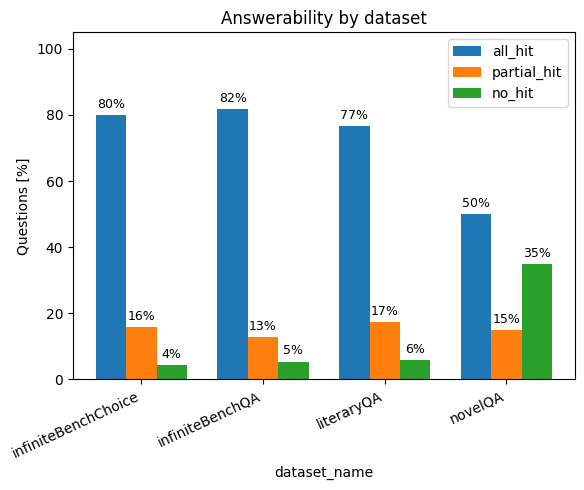

In [13]:
plot_answerability_percent(
    question_answerability,
    "dataset_name",
    "Answerability by dataset"
)

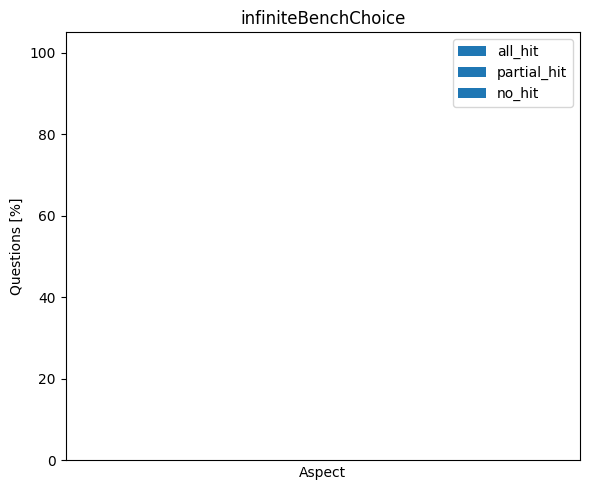

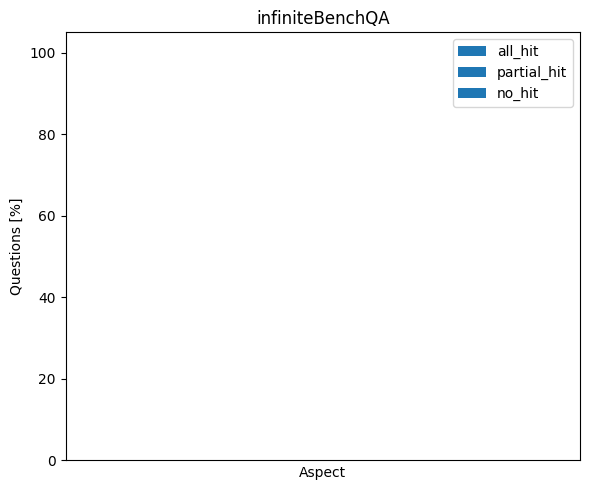

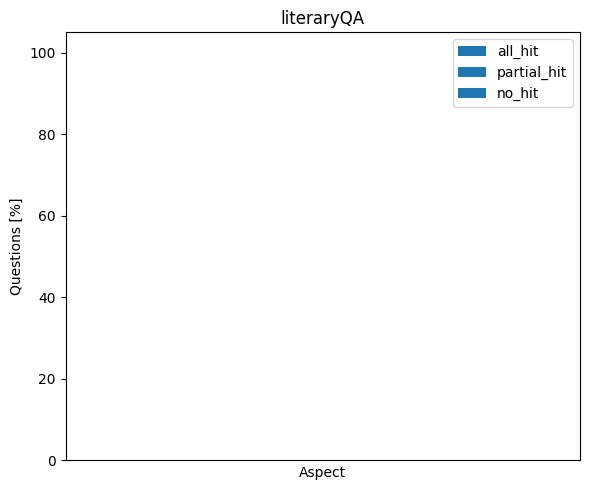

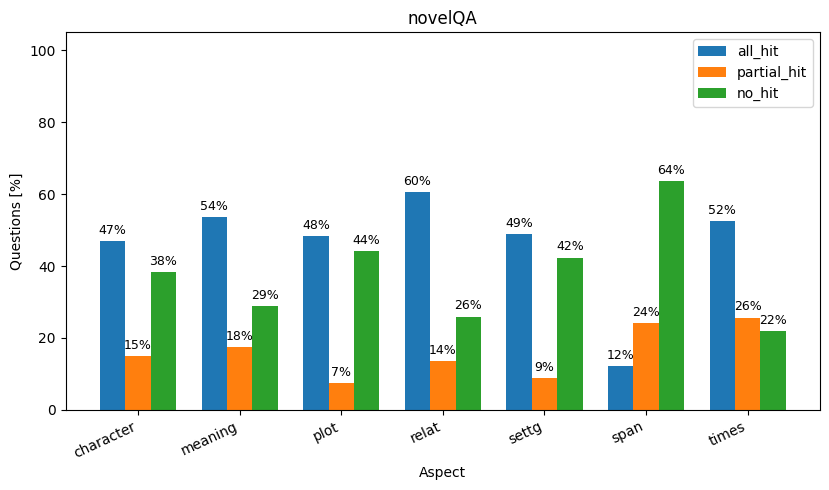

In [14]:
for dataset, df in question_answerability.groupby("dataset_name"):
    plot_answerability_percent(
        df,
        "Aspect",
        f"{dataset}"
    )

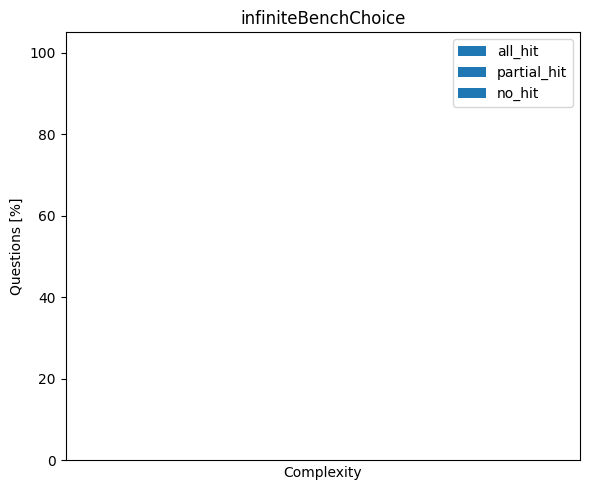

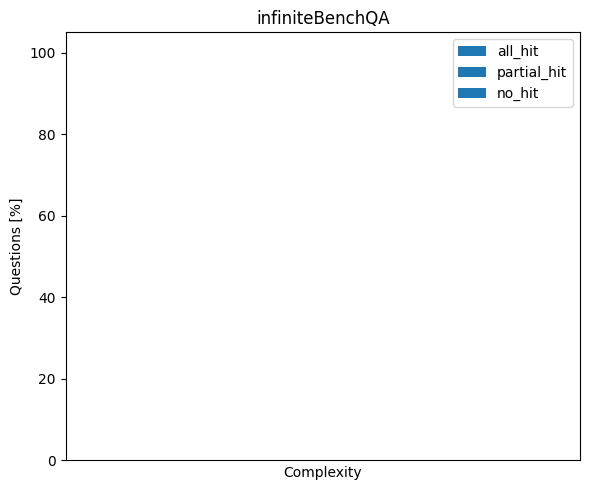

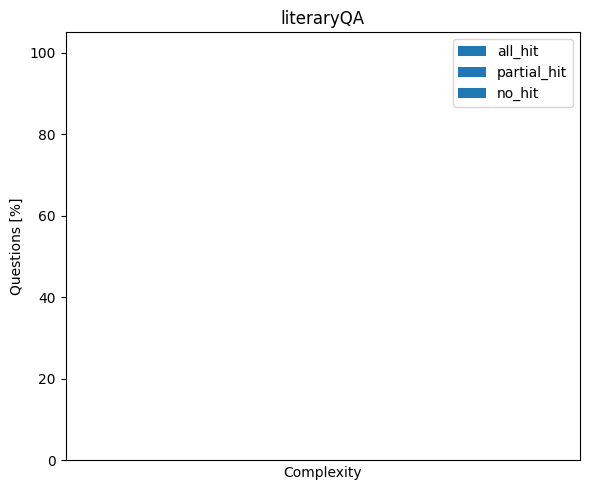

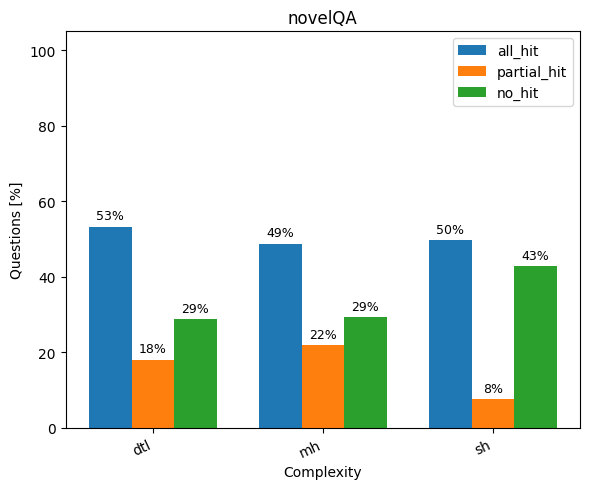

In [15]:
for dataset, df in question_answerability.groupby("dataset_name"):
    plot_answerability_percent(
        df,
        "Complexity",
        f"{dataset}"
    )

In [16]:
a = question_chunk_stats[(question_chunk_stats['dataset_name'] == 'novelQA') & (question_chunk_stats['chunking_name'] == 'chonkie_semantic')]
a

,dataset_name,dataset_params_name,chunking_name,chunking_params_name,question_id,split_name,chosen_good_num,chosen_bad_num,chosen_good,chosen_bad,source_file,Aspect,Complexity,Question,Options,Answers
34920,novelQA,default,chonkie_semantic,norm,Q0000,all,10,0,True,False,B56,times,mh,"In the novel Ayala's Angel, has Ayala ever scr...","[No, never, Yes, 1, Yes, 2, Yes, 3]",NaN
34921,novelQA,default,chonkie_semantic,norm,Q0001,all,9,1,True,True,B56,times,mh,How many times have Mr. Houston and Mrs. Docim...,"[Twice, Once, Three times, Four times]",NaN
34922,novelQA,default,chonkie_semantic,norm,Q0002,all,10,0,True,False,B56,relat,mh,Who are in the Tringle family?,"[Gertrude Tringle, Ayala Tringle, Lucy Tringle...",NaN
34923,novelQA,default,chonkie_semantic,norm,Q0003,all,6,4,True,True,B56,relat,dtl,What is the relationship between Tom and Lout?,"[Tom is Lout's brother, Tom is Lout's cousin, ...",NaN
34924,novelQA,default,chonkie_semantic,norm,Q0004,all,10,0,True,False,B56,meaning,dtl,"In the novel Ayala's Angel, in which chapter d...","[Chapter 10, Chapter 15, Chapter 12, Chapter 18]",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37198,novelQA,default,chonkie_semantic,norm,Q2300,all,0,10,False,True,B72,plot,dtl,"In the novel Satantango, what is the doctor's ...","[Leather., Canvas, Metal, Plastic]",NaN
37199,novelQA,default,chonkie_semantic,norm,Q2301,all,0,10,False,True,B72,meaning,sh,"In the novel Satantango, why didn't the doctor...","[He was afraid of getting lost on the way., He...",NaN
37200,novelQA,default,chonkie_semantic,norm,Q2302,all,0,10,False,True,B72,meaning,sh,"In the novel Satantango, why didn't the doctor...","[Because his cigars were soaked in the rain., ...",NaN
37201,novelQA,default,chonkie_semantic,norm,Q2303,all,0,10,False,True,B72,character,sh,Who is the youngest of the Horgos children?,"[Attila, Esti, Istvan, Reka]",NaN


In [17]:
chunker_results = (
    question_chunk_stats
    .groupby(
        [
            "dataset_name",
            "chunking_name",
            "chunking_params_name",
        ]
    )
    .agg(
        answered=("chosen_good", "sum"),
        total_questions=("chosen_good", "size"),
    )
    .reset_index()
)

# etykieta chunkera (jeśli parametrów nie ma, zostaje sama nazwa)
chunker_results["chunker"] = chunker_results.apply(
    lambda r: (
        r["chunking_name"]
        if pd.isna(r["chunking_params_name"]) or r["chunking_params_name"] == ""
        else f'{r["chunking_name"]}\n({r["chunking_params_name"]})'
    ),
    axis=1,
)

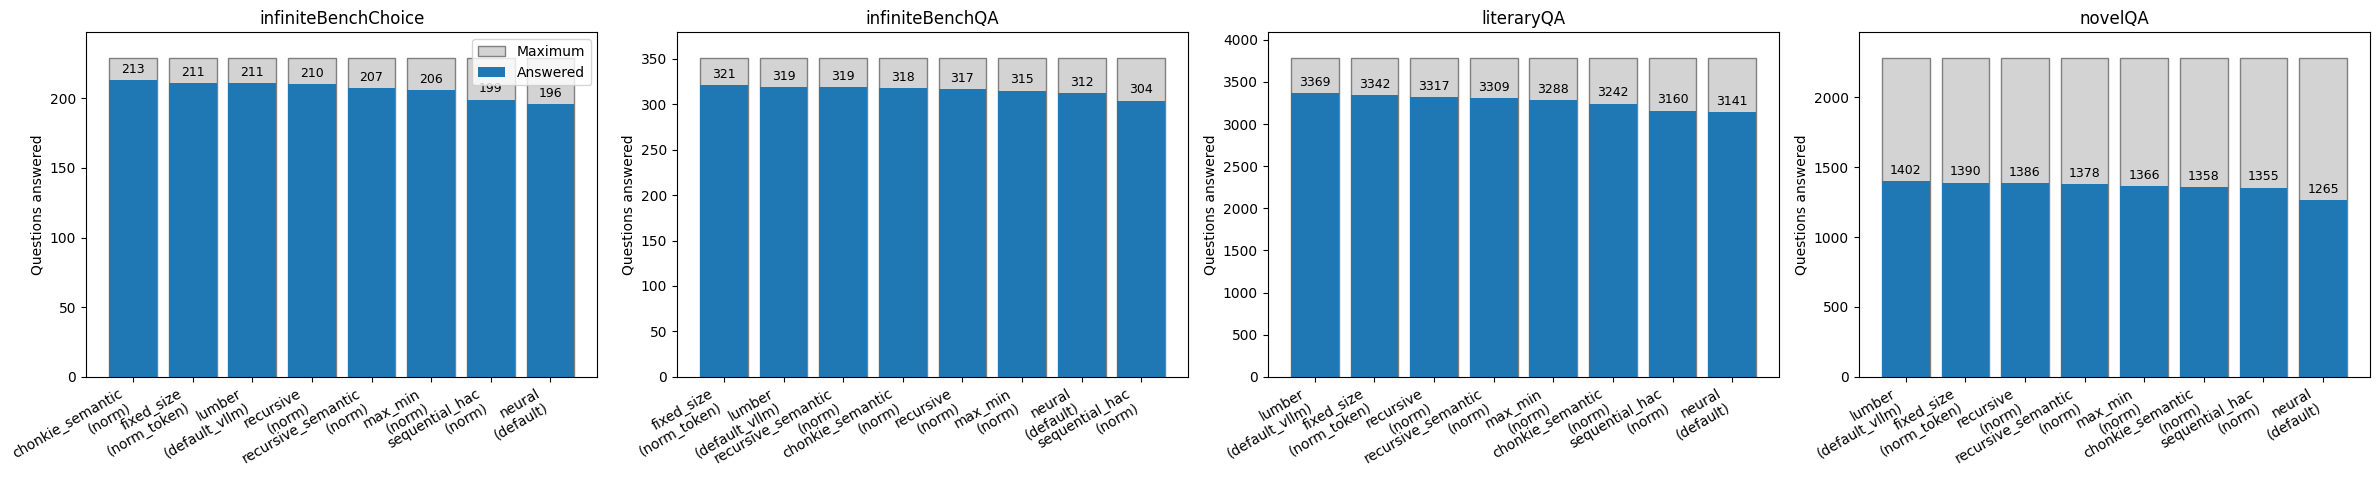

In [18]:
import matplotlib.pyplot as plt
import numpy as np

datasets = chunker_results["dataset_name"].unique()

fig, axes = plt.subplots(
    1,
    len(datasets),
    figsize=(6 * len(datasets), 5),
    sharey=False,
)

if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):

    df = (
        chunker_results[
            chunker_results["dataset_name"] == dataset
        ]
        .sort_values("answered", ascending=False)
    )

    x = np.arange(len(df))

    # ciemne tło = maksimum
    ax.bar(
        x,
        df["total_questions"],
        color="lightgray",
        edgecolor="gray",
        label="Maximum",
    )

    # jasny słupek = wynik
    bars = ax.bar(
        x,
        df["answered"],
        label="Answered",
    )

    ax.bar_label(
        bars,
        padding=3,
        fontsize=9,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        df["chunker"],
        rotation=30,
        ha="right",
    )

    ax.set_title(dataset)
    ax.set_ylabel("Questions answered")
    ax.set_ylim(0, df["total_questions"].max() * 1.08)

axes[0].legend()

plt.tight_layout()
plt.show()

In [19]:
def prepare_chunker_performance(group_col):
    """
    group_col: "Aspect" lub "Complexity"
    """

    return (
        question_chunk_stats
        .groupby(
            [
                "dataset_name",
                group_col,
                "chunking_name",
                "chunking_params_name",
            ]
        )
        .agg(
            answered=("chosen_good", "sum"),
            total_questions=("chosen_good", "size"),
        )
        .reset_index()
    )

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


def plot_chunker_performance(group_col):
    perf = prepare_chunker_performance(group_col).copy()

    # etykieta chunkera (nazwa + ewentualne parametry)
    perf["chunker"] = perf.apply(
        lambda r: r["chunking_name"]
        if pd.isna(r["chunking_params_name"]) or r["chunking_params_name"] == ""
        else f'{r["chunking_name"]} ({r["chunking_params_name"]})',
        axis=1,
    )

    # sortowanie: grupa -> dataset -> answered (malejąco), żeby bary "jedne pod drugim"
    # były sensownie pogrupowane
    perf = perf.sort_values(
        [group_col, "dataset_name", "answered"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    # kolory PER CHUNKER (a nie per dataset, jak było wcześniej)
    chunkers = sorted(perf["chunker"].unique())
    cmap = plt.get_cmap("tab20")
    chunker_colors = {ch: cmap(i % 20) for i, ch in enumerate(chunkers)}

    # Etykieta wiersza to TYLKO nazwa chunkera (jak prosiłeś).
    # Żeby nie zgubić informacji "jaka grupa / jaki dataset" - wstawiamy
    # przed każdym blokiem chunkerów osobny wiersz-nagłówek z opisem
    # grupy i datasetu (bold, bez bara), plus linie oddzielające bloki.
    records = []
    for (g, d), block in perf.groupby([group_col, "dataset_name"], sort=False):
        records.append({
            "row_label": f"{g}",
            "chunker": None,
            "total_questions": np.nan,
            "answered": np.nan,
            "is_header": True,
            "group": g,
        })
        for _, r in block.iterrows():
            records.append({
                "row_label": r["chunker"],
                "chunker": r["chunker"],
                "total_questions": r["total_questions"],
                "answered": r["answered"],
                "is_header": False,
                "group": g,
            })
            print(records[-1]['row_label'], records[-1]['answered'], records[-1]['group'])

    rows = pd.DataFrame(records)
    n = len(rows)
    y = np.arange(n)

    fig, ax = plt.subplots(figsize=(11, max(4, 0.38 * n)))

    mask = ~rows["is_header"]

    # tło - total_questions (zostaje szare, jak było) - tylko dla wierszy z danymi
    ax.barh(
        y[mask],
        rows.loc[mask, "total_questions"],
        color="lightgray",
        edgecolor="gray",
        label="Total questions",
        zorder=1,
    )

    # wynik - answered, kolor zależny od chunkera
    bar_colors = rows.loc[mask, "chunker"].map(chunker_colors)
    bars = ax.barh(y[mask], rows.loc[mask, "answered"], color=bar_colors, zorder=2)
    ax.bar_label(bars, fontsize=8, padding=2)

    # etykiety osi Y - tylko nazwa chunkera; wiersze-nagłówki bez tick label
    yticklabels = ["" if h else lbl for h, lbl in zip(rows["is_header"], rows["row_label"])]
    ax.set_yticks(y)
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.invert_yaxis()  # pierwszy wiersz na górze, jak w tabeli

    # nagłówki sekcji (grupa — dataset) jako pogrubiony tekst nad blokiem
    # + linie oddzielające: ciągła czarna przy zmianie grupy, przerywana szara przy zmianie datasetu
    x_max = rows["total_questions"].max()
    for idx in rows.index[rows["is_header"]]:
        ax.text(
            x_max * 0.01,
            idx,
            rows.loc[idx, "row_label"],
            fontsize=9,
            fontweight="bold",
            va="center",
            ha="left",
            zorder=3,
        )
        if idx > 0:
            same_group = rows.loc[idx, "group"] == rows.loc[idx - 1, "group"]
            ax.axhline(
                idx - 0.5,
                color="gray" if same_group else "black",
                linewidth=0.7 if same_group else 1.2,
                linestyle="--" if same_group else "-",
            )

    ax.set_xlabel("Liczba pytań")
    ax.set_title(f"Wydajność chunkerów wg: {group_col}")

    # legenda: total questions + jeden wpis na każdy chunker
    handles = [mpatches.Patch(facecolor="lightgray", edgecolor="gray", label="Total questions")]
    handles += [mpatches.Patch(facecolor=chunker_colors[ch], label=ch) for ch in chunkers]
    ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

In [5]:
import os


def szukaj_podstringu_w_txt(sciezka, podstring):
    """
    Przeszukuje wszystkie pliki .txt w podanej ścieżce
    i zwraca listę plików zawierających podany podstring.
    """
    znalezione = []

    for katalog, _, pliki in os.walk(sciezka):
        for plik in pliki:
            if plik.lower().endswith(".txt"):
                pelna_sciezka = os.path.join(katalog, plik)

                try:
                    with open(pelna_sciezka, "r", encoding="utf-8") as f:
                        tresc = f.read()

                    if podstring in tresc:
                        znalezione.append(pelna_sciezka)

                except (UnicodeDecodeError, PermissionError):
                    pass

    return znalezione


# Przykład użycia
sciezka = r"/home/mahuk/chunking-thesis/data/datasets"
szukany_tekst = "H M S Calypso"

wyniki = szukaj_podstringu_w_txt(sciezka, szukany_tekst)

for plik in wyniki:
    print(f"Znaleziono w: {plik}")

Znaleziono w: /home/mahuk/chunking-thesis/data/datasets/infiniteBenchQA/default/Books/all/14.txt
Znaleziono w: /home/mahuk/chunking-thesis/data/datasets/infiniteBenchQA/default/Books/train/14.txt
Znaleziono w: /home/mahuk/chunking-thesis/data/datasets/infiniteBenchChoice/default/Books/all/42.txt
Znaleziono w: /home/mahuk/chunking-thesis/data/datasets/infiniteBenchChoice/default/Books/train/42.txt


In [14]:
import pandas as pd

data = {
    "recursive": [16.4, 20.1, 113.8, 20.1],
    "fixed_size": [16.1, 19.5, 107.9, 21.8],
    "semantic": [19.5, 20.8, 119.1, 31.6],
    "sequential": [3.5, 4.6, 29.0, 5.1],
    "max_min": [16.5, 20.2, 117.0, 19.4],
    "neural": [3.4, 4.6, 26.7, 2.9],
    "recursive_semantic": [16.2, 19.9, 112.1, 19.5],
    "lumber": [16.5, 19.8, 112.9, 20.4]
}

df = pd.DataFrame(data)

# średnia dla każdego chunkera
avg = df.mean()

# format LaTeX
print("AVG & " + " & ".join([f"{x:.1f}K" for x in avg]) + r" \\")

AVG & 42.6K & 41.3K & 47.7K & 10.6K & 43.3K & 9.4K & 41.9K & 42.4K \\


In [8]:
df

,Dataset,recursive,fixed_size,semantic,sequential,max_min,neural,recursive_semantic,lumber,AVG
0,∞BenchChoice,16.4,16.1,19.5,3.5,16.5,3.4,16.2,16.5,13.5
1,∞BenchQA,20.1,19.5,20.8,4.6,20.2,4.6,19.9,19.8,16.2
2,literaryQA,113.8,107.9,119.1,29.0,117.0,26.7,112.1,112.9,92.3
3,novelQA,20.1,21.8,31.6,5.1,19.4,2.9,19.5,20.4,17.6


In [ ]:
def average_row(table_string):
    lines = [line.strip() for line in table_string.strip().split("\n") if line.strip()]

    rows = []
    for line in lines:
        parts = [p.strip() for p in line.replace("\\\\", "").split("&")]
        values = list(map(float, parts[1:]))  # pomijamy nazwę wiersza
        rows.append(values)

    n_cols = len(rows[0])

    averages = []
    for col in range(n_cols):
        avg = sum(row[col] for row in rows) / len(rows)
        averages.append(f"{avg:.4f}")

    return "AVG & " + " & ".join(averages) + r" \\"


# ===== Przykład =====
s = r"""
$\infty$BenchChoice & 11.82 & 11.69 & 11.76 & 15.13 & 12.04 & 19.32 & 11.94 & 11.75 \\
$\infty$BenchQA & 9.62 & 9.65 & 9.63 & 13.04 & 10.07 & 15.48 & 9.56 & 9.46 \\
literaryQA & 8.44 & 8.58 & 7.44 & 15.94 & 7.95 & 19.73 & 8.45 & 7.75 \\
novelQA & 0.93 & 0.95 & 0.81 & 1.74 & 0.22 & 2.22 &  0.94 & 0.86 \\
"""

print(average_row(s))

AVG & 7.7025 & 7.7175 & 7.4100 & 11.4625 & 7.5700 & 14.1875 & 7.7225 & 7.4550 \\


In [ ]:
def convert_to_percentages(input_string, X):
    parts = [p.strip() for p in input_string.replace("\\\\", "").split("&")]

    result = [parts[0]]  # pierwszy element (np. "Character")

    for value in parts[1:]:
        percentage = float(value) / X * 100
        result.append(f"{percentage:.2f}")

    return " & ".join(result) + r" \\"


# ===== Przykład użycia =====
s = "Multi-hop  & 494 & 502 & 491 & 493 & 488 & 462 & 493 & 512 \\\\"
X = 572

print(convert_to_percentages(s, X))

Multi-hop & 86.36 & 87.76 & 85.84 & 86.19 & 85.31 & 80.77 & 86.19 & 89.51 \\


{'row_label': 'lumber (default_vllm)', 'chunker': 'lumber (default_vllm)', 'total_questions': 418, 'answered': 251, 'is_header': False, 'group': 'character'}
{'row_label': 'recursive (norm)', 'chunker': 'recursive (norm)', 'total_questions': 418, 'answered': 249, 'is_header': False, 'group': 'character'}
{'row_label': 'fixed_size (norm_token)', 'chunker': 'fixed_size (norm_token)', 'total_questions': 418, 'answered': 248, 'is_header': False, 'group': 'character'}
{'row_label': 'recursive_semantic (norm)', 'chunker': 'recursive_semantic (norm)', 'total_questions': 418, 'answered': 244, 'is_header': False, 'group': 'character'}
{'row_label': 'chonkie_semantic (norm)', 'chunker': 'chonkie_semantic (norm)', 'total_questions': 418, 'answered': 243, 'is_header': False, 'group': 'character'}
{'row_label': 'max_min (norm)', 'chunker': 'max_min (norm)', 'total_questions': 418, 'answered': 241, 'is_header': False, 'group': 'character'}
{'row_label': 'sequential_hac (norm)', 'chunker': 'sequentia

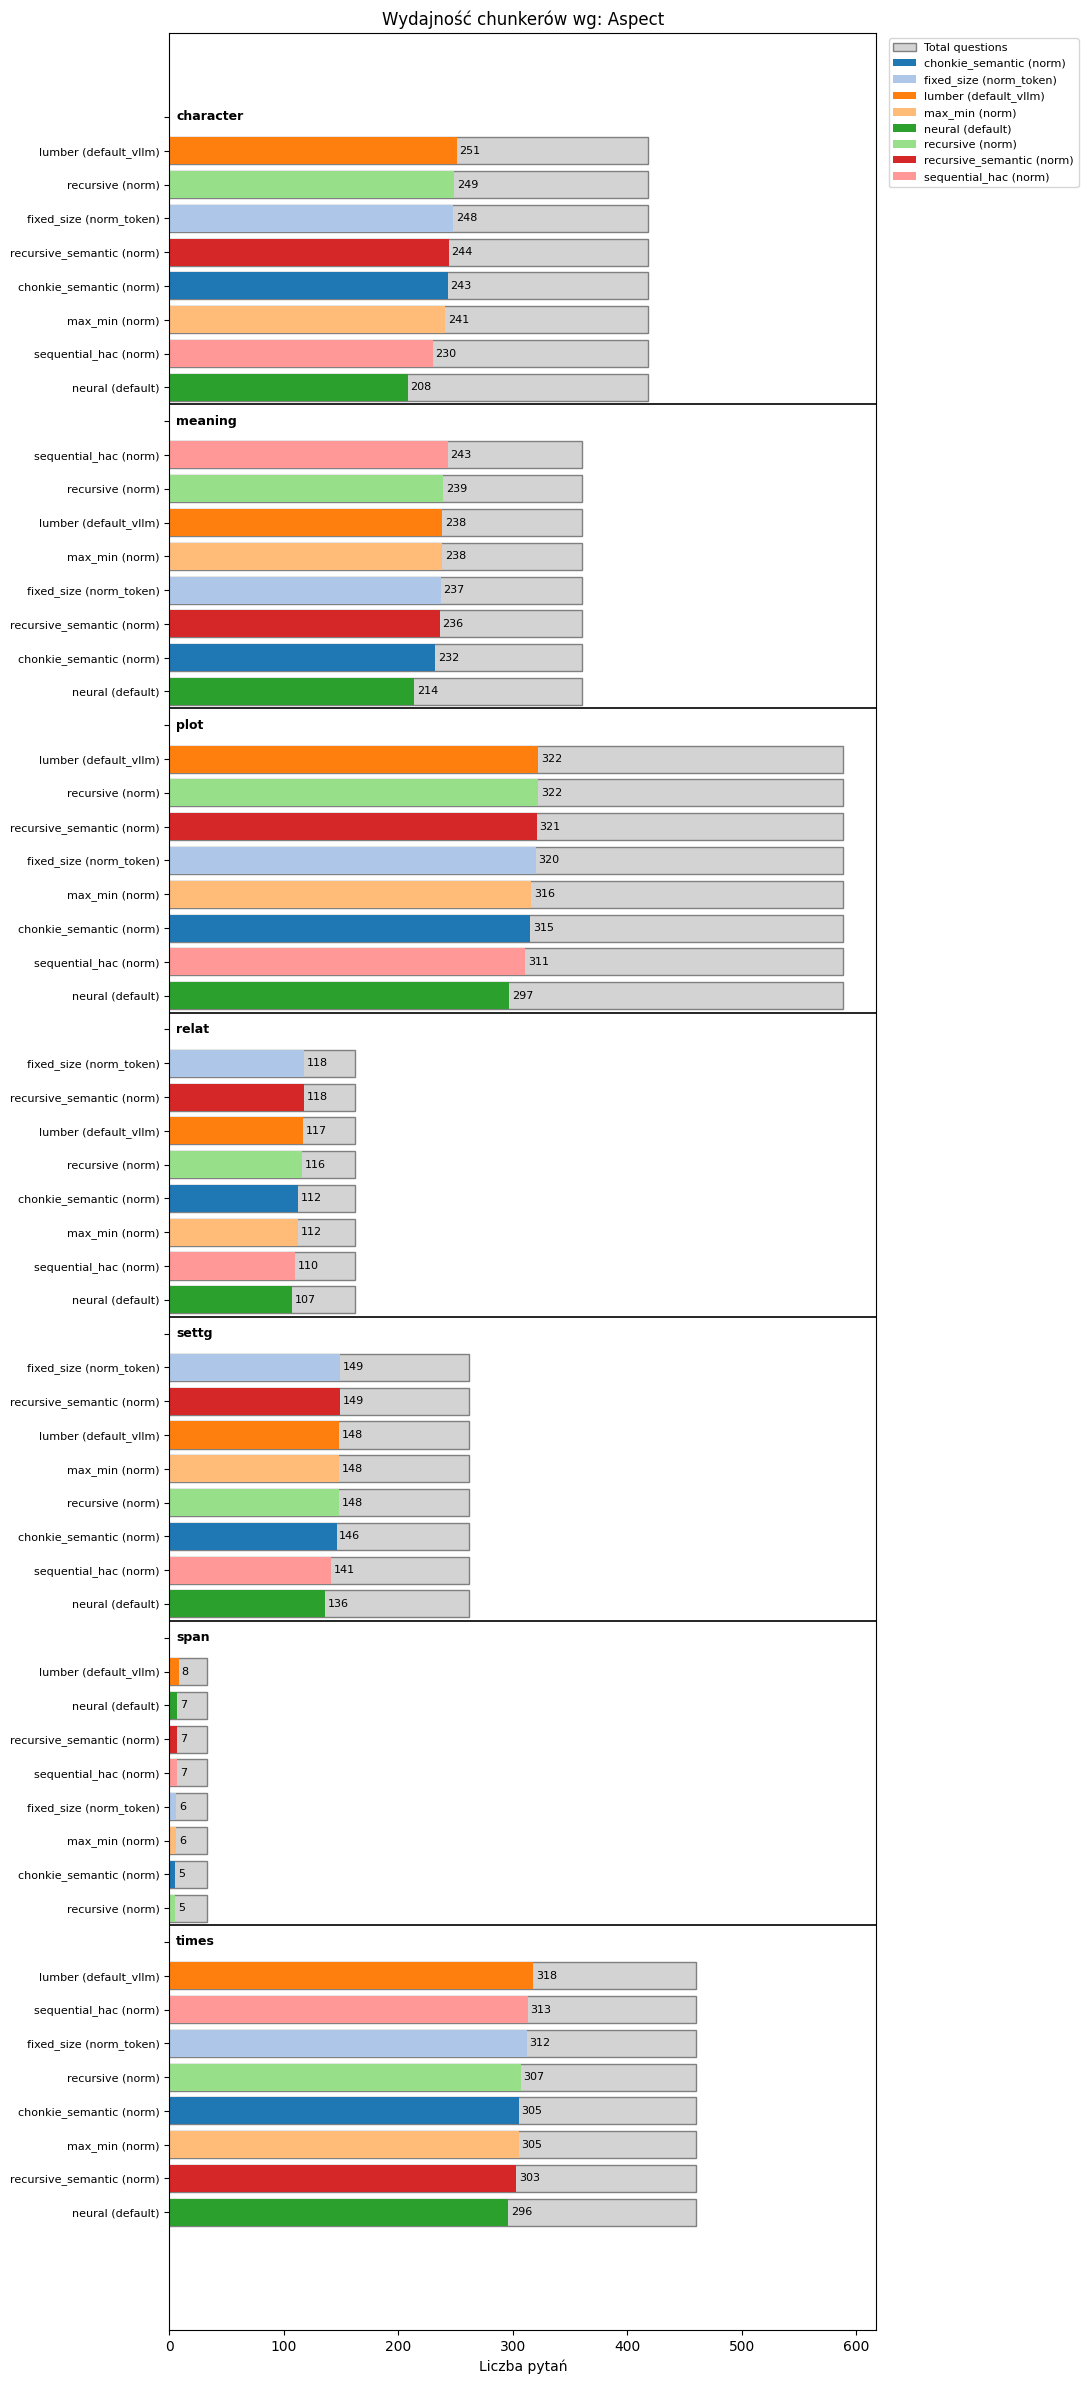

In [35]:
plot_chunker_performance("Aspect")

lumber (default_vllm) 344 dtl
recursive (norm) 344 dtl
fixed_size (norm_token) 343 dtl
recursive_semantic (norm) 339 dtl
max_min (norm) 337 dtl
chonkie_semantic (norm) 331 dtl
sequential_hac (norm) 328 dtl
neural (default) 292 dtl
lumber (default_vllm) 512 mh
fixed_size (norm_token) 502 mh
recursive (norm) 494 mh
recursive_semantic (norm) 493 mh
sequential_hac (norm) 493 mh
chonkie_semantic (norm) 491 mh
max_min (norm) 488 mh
neural (default) 462 mh
recursive (norm) 548 sh
lumber (default_vllm) 546 sh
recursive_semantic (norm) 546 sh
fixed_size (norm_token) 545 sh
max_min (norm) 541 sh
chonkie_semantic (norm) 536 sh
sequential_hac (norm) 534 sh
neural (default) 511 sh


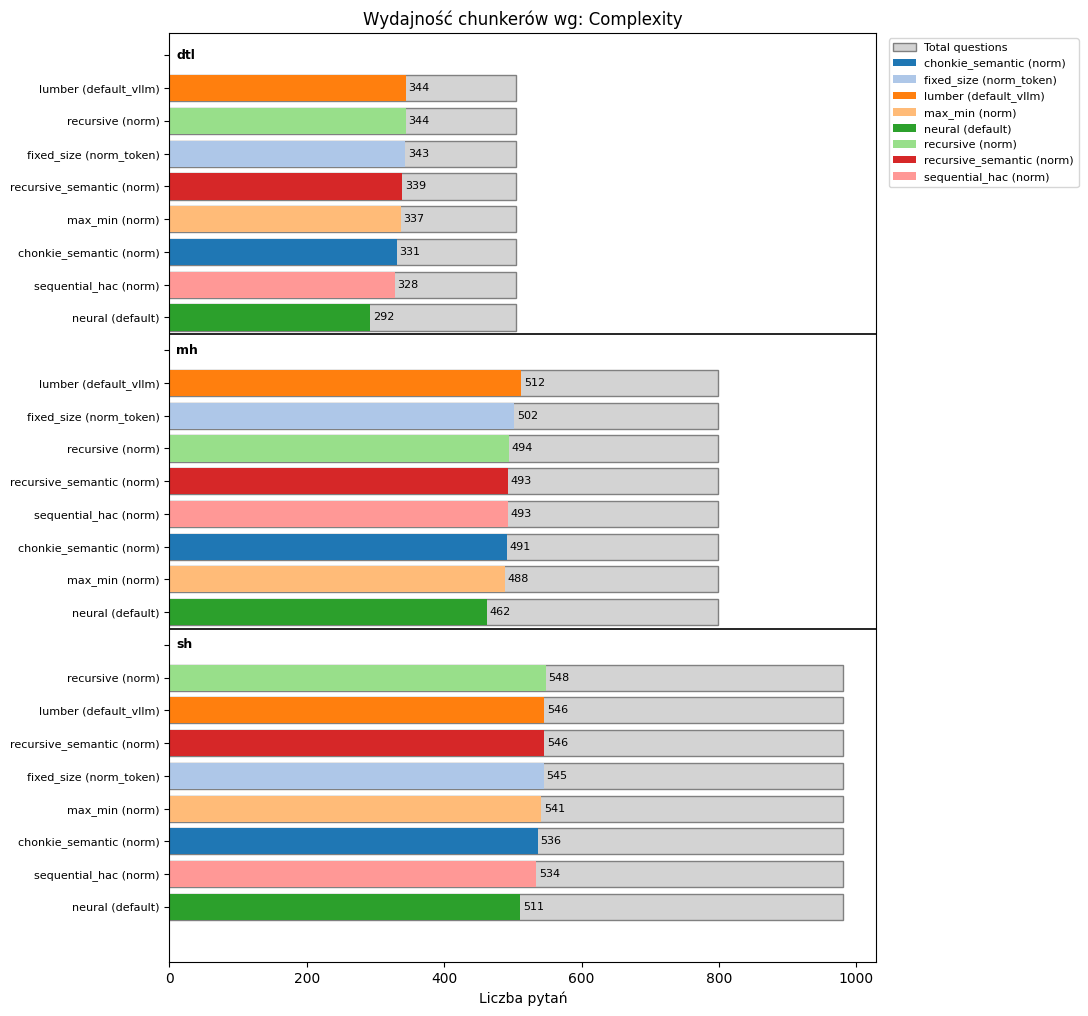

In [42]:
plot_chunker_performance("Complexity")